# 1B.3 Pandas - werken met echte data

In [1B.2 Pandas](1B.2-pandas.ipynb) maakten we kennis met de basis-bouwstenen van Pandas: de `Series` en de `DataFrame`. Hier gaan we verder met een echte dataset (COVID-19 cijfers) en bekijken we hoe je data inleest, bevraagt, opschoont, combineert en terug wegschrijft.

In [1]:
import pandas as pd
import numpy as np

### Lezen vanuit een bestand

Uiteraard is de meeste data beschikbaar in een vooropgeslagen formaat, zoals een Excel-bestand of een comma separated values (CSV)-bestand. Hieronder lezen we zo'n CSV-file in met de functie `read_csv()` (bron data: https://epistat.sciensano.be/covid/):

In [2]:
covid = pd.read_csv('COVID19BE_CASES_AGESEX.csv')
covid

,DATE,PROVINCE,REGION,AGEGROUP,SEX,CASES
0,2020-03-01,Antwerpen,Flanders,40-49,M,1
1,2020-03-01,Brussels,Brussels,10-19,F,1
2,2020-03-01,Brussels,Brussels,10-19,M,1
3,2020-03-01,Brussels,Brussels,20-29,M,1
4,2020-03-01,Brussels,Brussels,30-39,F,1
...,...,...,...,...,...,...
66170,NaN,VlaamsBrabant,Flanders,40-49,M,3
66171,NaN,VlaamsBrabant,Flanders,50-59,M,1
66172,NaN,WestVlaanderen,Flanders,20-29,F,1
66173,NaN,WestVlaanderen,Flanders,50-59,M,3


We kunnen met de functies `head()` en `tail()` de eerste respectievelijk laatste rijen opvragen. Een argument kan meegegeven worden om aan te duiden hoeveel rijen we willen (standaard = 5):

In [3]:
covid.head(3)

,DATE,PROVINCE,REGION,AGEGROUP,SEX,CASES
0,2020-03-01,Antwerpen,Flanders,40-49,M,1
1,2020-03-01,Brussels,Brussels,10-19,F,1
2,2020-03-01,Brussels,Brussels,10-19,M,1


In [4]:
covid.tail(8)

,DATE,PROVINCE,REGION,AGEGROUP,SEX,CASES
66167,NaN,OostVlaanderen,Flanders,NaN,F,4
66168,NaN,OostVlaanderen,Flanders,NaN,M,2
66169,NaN,VlaamsBrabant,Flanders,40-49,F,2
66170,NaN,VlaamsBrabant,Flanders,40-49,M,3
66171,NaN,VlaamsBrabant,Flanders,50-59,M,1
66172,NaN,WestVlaanderen,Flanders,20-29,F,1
66173,NaN,WestVlaanderen,Flanders,50-59,M,3
66174,NaN,NaN,NaN,NaN,NaN,1


### Kolommen

De naam van de kolommen kunnen opgevraagd worden onder het attribuut `columns`. Daarnaast kunnen de verschillende kolommen ook apart opgevraagd worden tussen vierkante haakjes (zoals een lijst-indexering dus):

In [5]:
print('Kolommen aanwezig:', covid.columns)
print('Een enkele kolom is een series:', type(covid['PROVINCE']))

Kolommen aanwezig: Index(['DATE', 'PROVINCE', 'REGION', 'AGEGROUP', 'SEX', 'CASES'], dtype='object')
Een enkele kolom is een series: <class 'pandas.core.series.Series'>


Een enkele kolom wordt als volgt opgevraagd:

In [6]:
covid['PROVINCE']

0             Antwerpen
1              Brussels
2              Brussels
3              Brussels
4              Brussels
              ...      
66170     VlaamsBrabant
66171     VlaamsBrabant
66172    WestVlaanderen
66173    WestVlaanderen
66174               NaN
Name: PROVINCE, Length: 66175, dtype: object

Het is ook mogelijk meerdere kolommen tegelijk te selecteren:

In [7]:
covid[['PROVINCE', 'REGION']].head(2)

,PROVINCE,REGION
0,Antwerpen,Flanders
1,Brussels,Brussels


Ten slotte kunnen kolommen ook nog hernoemd worden dmv een dictionary met als sleutels de oude kolomnamen en als waarden de nieuwe kolomnamen:

In [8]:
kolom_map = {'PROVINCE': 'provincie', 'REGION': 'regio'}
covid = covid.rename(columns=kolom_map)
covid.head(3)

,DATE,provincie,regio,AGEGROUP,SEX,CASES
0,2020-03-01,Antwerpen,Flanders,40-49,M,1
1,2020-03-01,Brussels,Brussels,10-19,F,1
2,2020-03-01,Brussels,Brussels,10-19,M,1


### Doorlopen rijen (als data)

Je kan de rijen ook 1-per-1 doorlopen met de `iterrows()` functie. Gelijkaardig aan `items()` in een dictionary geeft deze iterator een tuple terug van de index van de rij en de data. Hieronder zal dus `rij_nummer` de index bevatten en `rij_data` een `Series` met daarin de cellen van de rij. Zo kan je ook weer bv. een enkele cel opvragen in de rij data door de vierkante haken te gebruiken, zoals hieronder gebeurt voor `provincie`:

In [9]:
for rij_nummer, rij_data in covid.iterrows():
    print('\nRij', rij_nummer)
    print(type(rij_data))
    print(rij_data)
    if rij_nummer > 5:
        break
    print('{0:6}, {1}'.format(rij_nummer, rij_data['provincie']))


Rij 0
<class 'pandas.core.series.Series'>
DATE         2020-03-01
provincie     Antwerpen
regio          Flanders
AGEGROUP          40-49
SEX                   M
CASES                 1
Name: 0, dtype: object
     0, Antwerpen

Rij 1
<class 'pandas.core.series.Series'>
DATE         2020-03-01
provincie      Brussels
regio          Brussels
AGEGROUP          10-19
SEX                   F
CASES                 1
Name: 1, dtype: object
     1, Brussels

Rij 2
<class 'pandas.core.series.Series'>
DATE         2020-03-01
provincie      Brussels
regio          Brussels
AGEGROUP          10-19
SEX                   M
CASES                 1
Name: 2, dtype: object
     2, Brussels

Rij 3
<class 'pandas.core.series.Series'>
DATE         2020-03-01
provincie      Brussels
regio          Brussels
AGEGROUP          20-29
SEX                   M
CASES                 1
Name: 3, dtype: object
     3, Brussels

Rij 4
<class 'pandas.core.series.Series'>
DATE         2020-03-01
provincie      Brussels


### Filteren

Ten slotte kunnen we ook data filteren op basis van de metadata, zoals bv. het datatype of gewoon de waarden in de cellen. Hieronder worden eerst enkel de numerieke kolommen van het type `int64` en `float64` overgehouden: 

In [10]:
numerische_kolommen = covid.select_dtypes(include=['int64', 'float64'])
numerische_kolommen.head(3)

,CASES
0,1
1,1
2,1


In dit voorbeeld is er maar 1 numerische kolom, 'CASES'.

We kunnen ook filteren op bepaalde waarden. Eerst op 1 enkele conditie, daarna op 2 condities gecombineerd met `&`. Je zal dus niet de standaard logische operators kunnen gebruiken, maar moet `&` gebruiken voor `and` en `|` voor `or`.

De dagen met meer dan 20 besmettingen:

In [11]:
df_filter_cases = covid[covid['CASES'] > 20]
df_filter_cases

,DATE,provincie,regio,AGEGROUP,SEX,CASES
2103,2020-03-23,Antwerpen,Flanders,60-69,M,21
2105,2020-03-23,Antwerpen,Flanders,70-79,M,27
2267,2020-03-23,WestVlaanderen,Flanders,50-59,M,22
2295,2020-03-24,Antwerpen,Flanders,60-69,M,23
2482,2020-03-25,Antwerpen,Flanders,50-59,M,21
...,...,...,...,...,...,...
66093,2021-03-17,WestVlaanderen,Flanders,10-19,M,25
66094,2021-03-17,WestVlaanderen,Flanders,20-29,F,22
66096,2021-03-17,WestVlaanderen,Flanders,30-39,F,23
66098,2021-03-17,WestVlaanderen,Flanders,40-49,F,23


Aantal dagen met meer dan 20 besmettingen in de provincie Antwerpen:

In [12]:
df_filter_antwerpen = covid[(covid['provincie'] == 'Antwerpen') & (covid['CASES'] > 20)]
print(len(df_filter_antwerpen))

1647


Analoog gebruiken we `|` voor een OF-conditie (or). Hieronder zoeken we de dagen met meer dan 100 besmettingen, of de dagen in de provincie Brussel (ongeacht het aantal besmettingen):

In [13]:
df_filter_or = covid[(covid['CASES'] > 100) | (covid['provincie'] == 'Brussels')]
print(len(df_filter_or))

7420


### Sorteren en groeperen

Ten slotte kan er ook makkelijk gesorteerd en gegroepeerd worden in Pandas. Sorteren gebeurt met de `sort_values()` functie die als argument een lijst van variabelen. De volgorde is belangrijk want er wordt eerst op het eerste element gesorteerd, dan het tweede, enzoverder:

In [14]:
df_gesorteerd = covid.sort_values(by=['provincie', 'CASES'])
df_gesorteerd

,DATE,provincie,regio,AGEGROUP,SEX,CASES
0,2020-03-01,Antwerpen,Flanders,40-49,M,1
16,2020-03-02,Antwerpen,Flanders,40-49,M,1
31,2020-03-03,Antwerpen,Flanders,30-39,F,1
32,2020-03-03,Antwerpen,Flanders,40-49,F,1
33,2020-03-03,Antwerpen,Flanders,40-49,M,1
...,...,...,...,...,...,...
27732,2020-10-01,NaN,NaN,NaN,NaN,37
27498,2020-09-30,NaN,NaN,NaN,M,38
32362,2020-10-20,NaN,NaN,30-39,M,38
33155,2020-10-23,NaN,NaN,20-29,M,41


Groeperen gebeurt met de `groupby()` functie dat als argument gewoon een lijst aanneemt. Ook hier speelt de volgorde een rol. Anders hier is dat er ook een aggregatiefunctie nodig is (net als in SQL). Hieronder wordt bv. het gemiddeld aantal cases (want 'CASE' is de enige numerieke kolom) per provincie per gender berekend:

In [15]:
df_gegroepeerd = covid.groupby(['provincie', 'SEX']).mean(numeric_only=True)
df_gegroepeerd

CASES
provincie      SEX           
Antwerpen      F    16.878144
               M    14.559720
BrabantWallon  F     7.443538
               M     6.728505
Brussels       F    17.205200
               M    15.040816
Hainaut        F    22.338078
               M    18.618507
Limburg        F     7.816667
               M     6.865580
Liège          F    20.261800
               M    17.312344
Luxembourg     F     6.212285
               M     5.506507
Namur          F     9.967206
               M     8.609306
OostVlaanderen F    16.451979
               M    13.584590
VlaamsBrabant  F    11.980683
               M    10.198866
WestVlaanderen F    13.486193
               M    10.984074

Merk op: je kan het gemiddelde/de mediaan/etc. enkel berekenen over getallen. Vandaar geven we `numeric_only=True` mee zodat Pandas automatisch enkel de numerische kolommen zal gebruiken in de aggregatie. Dit is recent veranderd in Pandas, het kan zijn dat dit niet hoeft/werkt in jouw versie.

### Verwijderen van data

Ten slotte kunnen we ook kolommen verwijderen door ze te 'droppen'. Om een kolom te verwijderen doen we dit langs de kolom-as, de 2de (index 1) as dus - net als in NumPy. We gebruiken de `drop()` functie met als argumenten een lijst met de kolommen die wegmoeten en het `axis`-argument: 

In [16]:
df_zonder_kolommen = covid.drop(['regio', 'SEX'], axis=1)
df_zonder_kolommen.head()

,DATE,provincie,AGEGROUP,CASES
0,2020-03-01,Antwerpen,40-49,1
1,2020-03-01,Brussels,10-19,1
2,2020-03-01,Brussels,10-19,1
3,2020-03-01,Brussels,20-29,1
4,2020-03-01,Brussels,30-39,1


Rijen kunnen ook per index verwijderd worden (gegeven dat de index numeriek is - maar dit is niet relevant voor de cursus). Hiervoor gebruiken we `drop()` (`axis` is niet nodig vermits we langs de default as, de rij-as verwijderen) en een collectie van indices. Hieronder verwijderen we om de 5 rijen een rij met een range:

In [17]:
indices_te_verwijderen = range(0, len(covid), 5)
print('Eerste 20 te verwijderen indices:', list(indices_te_verwijderen)[:20])
print('Lengte DF ervoor:', len(covid))
df_zonder_rijen = covid.drop(indices_te_verwijderen)
print('Lengte DF erna:', len(df_zonder_rijen))

Eerste 20 te verwijderen indices: [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95]
Lengte DF ervoor: 66175
Lengte DF erna: 52940


### Combineren van DataFrames

Soms staat data verspreid over meerdere `DataFrame`-objecten die je wil samenvoegen. Pandas voorziet hiervoor twee functies: `concat()` om DataFrames met dezelfde kolommen onder elkaar te plakken (rijen toevoegen), en `merge()` om twee DataFrames te combineren op basis van een gemeenschappelijke kolom (net als een JOIN in SQL).

In [18]:
deel_1 = pd.DataFrame({'naam': ['robin', 'ted'], 'aantal': [10, 20]})
deel_2 = pd.DataFrame({'naam': ['barney', 'lilly'], 'aantal': [30, 40]})
pd.concat([deel_1, deel_2], ignore_index=True)

,naam,aantal
0,robin,10
1,ted,20
2,barney,30
3,lilly,40


`merge()` gebruiken we hier om de covid-data te verrijken met de hoofdstad van elke regio. We geven aan op welke kolom er gematcht moet worden met `on`:

In [19]:
regio_info = pd.DataFrame({
    'regio': ['Flanders', 'Wallonia', 'Brussels'],
    'hoofdstad': ['Brussel', 'Namen', 'Brussel'],
})
covid.merge(regio_info, on='regio').head(3)

,DATE,provincie,regio,AGEGROUP,SEX,CASES,hoofdstad
0,2020-03-01,Antwerpen,Flanders,40-49,M,1,Brussel
1,2020-03-01,Brussels,Brussels,10-19,F,1,Brussel
2,2020-03-01,Brussels,Brussels,10-19,M,1,Brussel


### Ontbrekende waarden

We zagen bij `Series` al dat Pandas overweg kan met ontbrekende waarden (`NaN`). Ook bij een `DataFrame` kunnen we die opsporen: `isna()` geeft per cel aan of ze leeg is, en gecombineerd met `sum()` per kolom krijgen we het aantal ontbrekende waarden per kolom:

In [20]:
covid.isna().sum()

DATE           49
provincie    4245
regio        4245
AGEGROUP     1836
SEX          1033
CASES           0
dtype: int64

Rijen met minstens 1 ontbrekende waarde kunnen we verwijderen met `dropna()`, of we kunnen ontbrekende waarden opvullen met een standaardwaarde via `fillna()`:

In [21]:
print('Lengte voor dropna:', len(covid))
covid_zonder_nan = covid.dropna()
print('Lengte na dropna:', len(covid_zonder_nan))

covid_opgevuld = covid.fillna({'AGEGROUP': 'onbekend', 'SEX': 'onbekend'})
covid_opgevuld['AGEGROUP'].value_counts()

Lengte voor dropna: 66175
Lengte na dropna: 59923


AGEGROUP
20-29       7630
40-49       7545
30-39       7521
50-59       7381
60-69       6690
70-79       6148
10-19       6142
80-89       5958
0-9         4959
90+         4365
onbekend    1836
Name: count, dtype: int64

### Grafieken

Pandas kan ook rechtstreeks grafieken tekenen via de `plot()` functie (die achter de schermen Matplotlib gebruikt). Hieronder groeperen we het totaal aantal besmettingen per dag en zetten we dit om in een lijngrafiek:

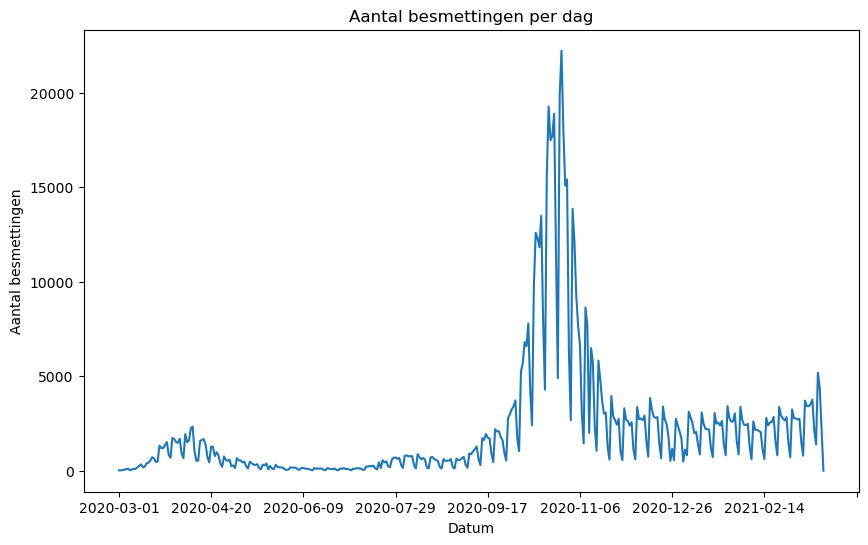

In [22]:
import matplotlib.pyplot as plt

covid_per_dag = covid.groupby('DATE')['CASES'].sum()

plt.figure(figsize=(10, 6))
covid_per_dag.plot()
plt.title('Aantal besmettingen per dag')
plt.xlabel('Datum')
plt.ylabel('Aantal besmettingen')
plt.show()

### Wegschrijven van data

Net zoals we data kunnen inlezen met `read_csv()`, kunnen we een `DataFrame` (of `Series`) ook terug wegschrijven met `to_csv()` (en analoog `to_excel()` voor Excel-bestanden, wat wel het `openpyxl`-package vereist). Met `index=False` zorgen we dat de Pandas-index niet als extra kolom wordt weggeschreven:

In [23]:
covid_per_dag.to_csv('covid_per_dag.csv', index=True)
df_zonder_kolommen.to_excel('covid_zonder_kolommen.xlsx', index=False)